# Árbol de regresión

Un árbol de regresión aprende **reglas de decisión** para dividir los datos en regiones y asignar una predicción a cada una.

A diferencia de la regresión lineal:
- No ajusta una recta o curva global
- Aprende **divisiones del tipo: si x < umbral**


In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## 1. Generación de datos

Creamos datos no lineales para ver cómo el árbol se adapta mediante particiones.

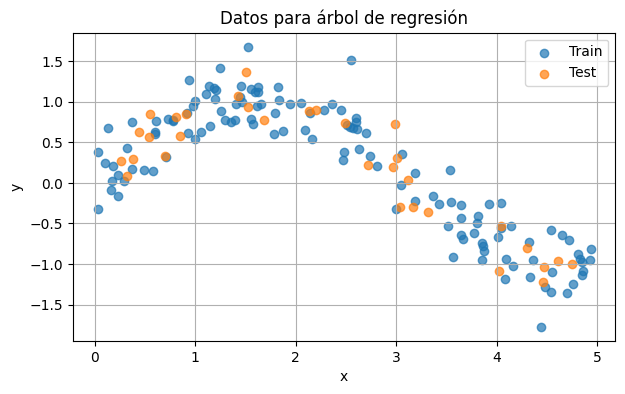

In [29]:
np.random.seed(42)

X = np.sort(5 * np.random.rand(160, 1), axis=0)
y = np.sin(X[:, 0]) + 0.25 * np.random.randn(160)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.figure(figsize=(7,4))
plt.scatter(X_train, y_train, alpha=0.7, label='Train')
plt.scatter(X_test, y_test, alpha=0.7, label='Test')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos para árbol de regresión')
plt.legend()
plt.grid(True)
plt.show()

## 2. Entrenamiento del modelo

In [30]:
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

MSE: 0.0662
R²: 0.8723


## 3. Visualización de la predicción

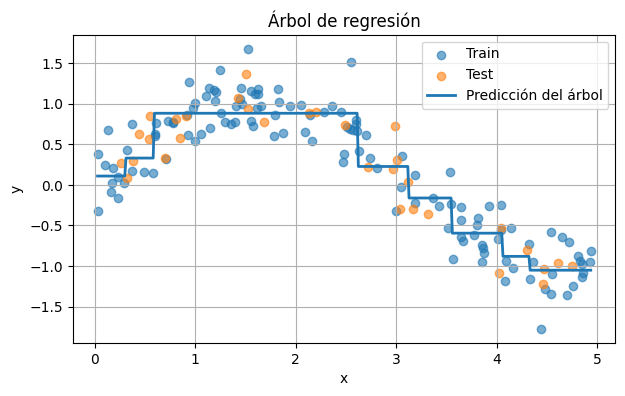

In [31]:
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
y_plot = tree.predict(X_plot)

plt.figure(figsize=(7,4))
plt.scatter(X_train, y_train, alpha=0.6, label='Train')
plt.scatter(X_test, y_test, alpha=0.6, label='Test')
plt.plot(X_plot, y_plot, linewidth=2, label='Predicción del árbol')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Árbol de regresión')
plt.legend()
plt.grid(True)
plt.show()

## 4. Visualización del árbol

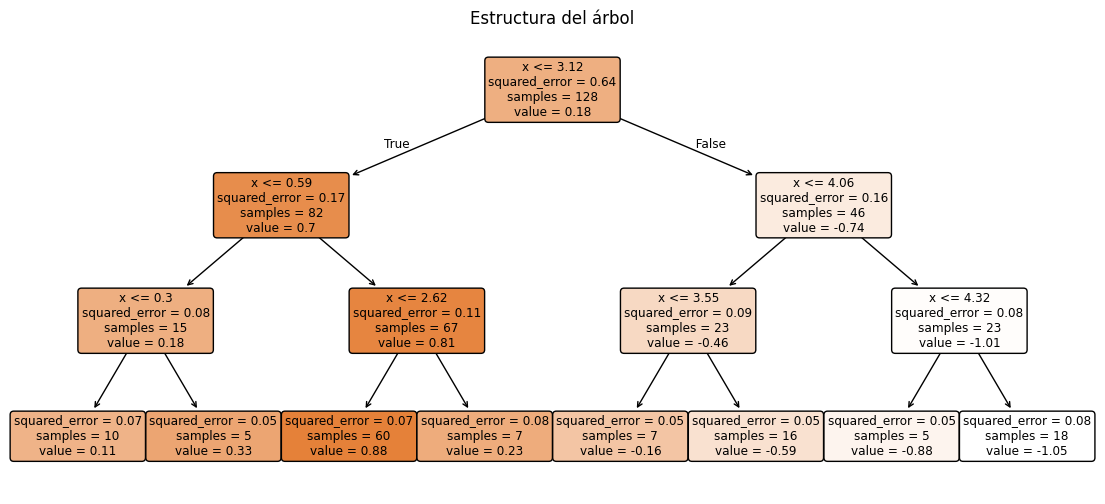

In [32]:
plt.figure(figsize=(14, 6))
plot_tree(
    tree,
    feature_names=['x'],
    filled=True,
    rounded=True,
    impurity=True,
    precision=2
)
plt.title('Estructura del árbol')
plt.show()

## 5. Comparación de distintas profundidades

- Profundidad baja → modelo simple
- Profundidad alta → modelo más flexible

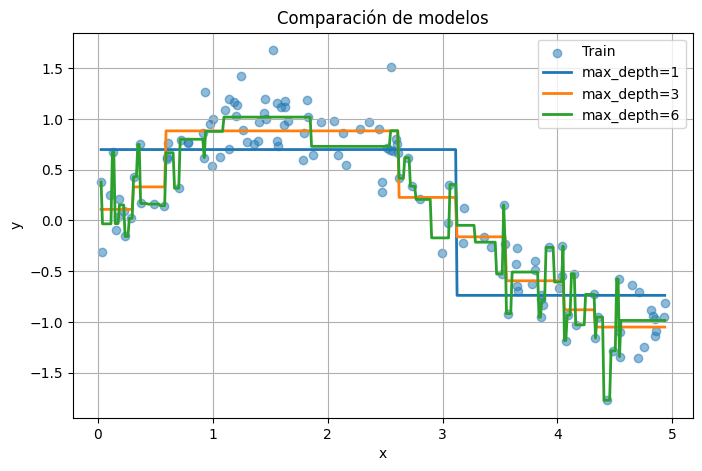

max_depth=1 -> MSE test: 0.1462
max_depth=3 -> MSE test: 0.0662
max_depth=6 -> MSE test: 0.1065


In [33]:
depths = [1, 3, 6]
resultados = []

plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, alpha=0.5, label='Train')

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_pred_d = model.predict(X_test)
    mse_d = mean_squared_error(y_test, y_pred_d)
    resultados.append((d, mse_d))

    y_plot_d = model.predict(X_plot)
    plt.plot(X_plot, y_plot_d, linewidth=2, label=f"max_depth={d}")

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparación de modelos')
plt.legend()
plt.grid(True)
plt.show()

for d, mse_d in resultados:
    print(f"max_depth={d} -> MSE test: {mse_d:.4f}")

## 6. Train vs Test

Para observar overfitting.

In [34]:
for d in [1, 3, 6, 10]:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    print(f"max_depth={d} -> MSE train: {mse_train:.4f} | MSE test: {mse_test:.4f}")

max_depth=1 -> MSE train: 0.1642 | MSE test: 0.1462
max_depth=3 -> MSE train: 0.0683 | MSE test: 0.0662
max_depth=6 -> MSE train: 0.0304 | MSE test: 0.1065
max_depth=10 -> MSE train: 0.0047 | MSE test: 0.1394


## 7. Conclusiones

- Aprende reglas, no una fórmula
- Captura relaciones no lineales
- Puede sobreajustar si es muy profundo

👉 La predicción aparece en forma de **escalones**

## 8. Ejercicios

1. Probar más valores de `max_depth`
2. Cambiar `min_samples_leaf`
3. Explicar visualmente los escalones
4. Comparar con regresión polinómica